# Лабораторная работа 2. Разведочный анализ данных (EDA)

Ноутбук анализирует разметку RUSLAN по словам и фонемам (MFA) и признаки для предиктора пауз.

**Разделы**
1. Загрузка и проверка данных
2. Статистики длительностей (буква, слово, гласная, фонема, пауза)
3. Классы пауз: пунктуация и KMeans
4. Корреляции признаков с целевыми переменными (классификация и регрессия)
5. Поиск технического шума
6. Выводы

Анализ ведётся на `train`-части

In [4]:
import csv
import os
import pathlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
from IPython.display import Audio, display
from praatio import textgrid
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

METADATA_PATH = 'data/RUSLAN_pause_metadata.csv'
FEATURES_PATH = 'data/RUSLAN_pause_features.csv'
ALIGN_DIR = '../../data/RUSLAN_align/v2/'

NOTEBOOK_DIR = pathlib.Path().resolve()
AUDIO_DIR = NOTEBOOK_DIR.parents[1] / 'data' / 'RUSLAN'

RANDOM_STATE = 42
SHORT_PAUSE_MS = 100
LONG_PAUSE_MS = 400
VOWELS = set('аоиеёэыуюя')
random.seed(RANDOM_STATE)

d:\documents\tts_labs_itmo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка и проверка данных

In [5]:
meta = pd.read_csv(METADATA_PATH, sep='|', quoting=csv.QUOTE_NONE)
feats = pd.read_csv(FEATURES_PATH, sep='|', quoting=csv.QUOTE_NONE)

print('metadata:', meta.shape, '| features:', feats.shape)
assert len(meta) == len(feats), 'Разная длина metadata и features -- пересоберите кеш (build_features_cache.py)'
assert (meta.id.values == feats.id.values).all(), 'Порядок id в metadata и features не совпадает'

# признаки лежат построчно в том же порядке, что и метаданные
df = pd.concat([meta, feats.drop(columns='id')], axis=1)
df.head()

metadata: (245609, 8) | features: (245609, 27)


,label,duration,id,label_raw,is_last_word,is_pause_after,pause_duration,set,punct_class,pos_prev2,...,tokens_to_end,is_next_cconj,next_is_stop,is_curr_noun_or_propn,is_curr_propn,has_quote_mark,is_not_last_sentence,n_sentences_in_id,tokens_to_next_comma,commas_left_in_clause
0,с,0.11,000000_RUSLAN,С,0,0,0.0,test,none,NONE,...,6,0,0,0,0,0,0,1,7,0
1,тревожным,0.58,000000_RUSLAN,тревожным,0,0,0.0,test,none,NONE,...,5,0,0,0,0,0,0,1,6,0
2,чувством,0.62,000000_RUSLAN,чувством,0,0,0.0,test,none,ADP,...,4,0,0,1,0,0,0,1,5,0
3,берусь,0.39,000000_RUSLAN,берусь,0,0,0.0,test,none,ADJ,...,3,0,0,0,0,0,0,1,4,0
4,я,0.09,000000_RUSLAN,я,0,0,0.0,test,none,NOUN,...,2,0,1,0,0,0,0,1,3,0


In [6]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('Категориальные / строковые столбцы:')
display(
    df[cat_cols].describe().T
    .assign(
        N_nan_values=df[cat_cols].isnull().sum(),
        # для label / label_raw / id список значений был бы огромным -- показываем только короткие
        unique_values=df[cat_cols].apply(lambda x: x.unique().tolist() if x.nunique() <= 20 else '...'),
    )
)

print('Числовые столбцы:')
display(
    df[num_cols].describe().T
    .assign(
        N_nan_values=df[num_cols].isnull().sum(),
        n_unique=df[num_cols].nunique(),
    )
)

print('Предложений (id):', df.id.nunique())
print('\nset:')
display(df.set.value_counts().to_frame('n_tokens').join(
    df.groupby('set').id.nunique().rename('n_sentences')))

Категориальные / строковые столбцы:


C:\Users\vanya\AppData\Local\Temp\ipykernel_13248\3245055514.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


,count,unique,top,freq,N_nan_values,unique_values
label,245609,46687,и,7120,0,...
id,245609,21255,019766_RUSLAN,113,0,...
label_raw,245609,74977,и,5456,0,...
set,245609,2,train,196710,0,"[test, train]"
punct_class,245609,9,none,179431,0,"[none, period, question, comma, exclaim, dash,..."
pos_prev2,245609,16,NOUN,52720,0,"[NONE, ADP, ADJ, NOUN, VERB, PRON, SCONJ, CCON..."
pos_prev1,245609,16,NOUN,56199,0,"[NONE, ADP, ADJ, NOUN, VERB, PRON, SCONJ, DET,..."
pos_curr,245609,16,NOUN,69025,0,"[ADP, ADJ, NOUN, VERB, PRON, SCONJ, DET, CCONJ..."
pos_next1,245609,17,NOUN,64951,0,"[ADJ, NOUN, VERB, PRON, ADP, NONE, DET, CCONJ,..."
pos_next2,245609,17,NOUN,60348,0,"[NOUN, VERB, PRON, ADP, NONE, ADJ, DET, ADV, C..."


Числовые столбцы:


,count,mean,std,min,25%,50%,75%,max,N_nan_values,n_unique
duration,245609.0,0.401457,0.221743,0.01,0.220000,0.4,0.550000,5.5583,0,9984
is_last_word,245609.0,0.086540,0.281160,0.00,0.000000,0.0,0.000000,1.0000,0,2
is_pause_after,245609.0,0.149563,0.356643,0.00,0.000000,0.0,0.000000,1.0000,0,2
pause_duration,245609.0,0.029655,0.093352,0.00,0.000000,0.0,0.000000,1.8700,0,735
word_len,245609.0,5.608101,3.224130,1.00,3.000000,5.0,8.000000,21.0000,0,21
n_syllables,245609.0,2.384815,1.368736,0.00,1.000000,2.0,3.000000,10.0000,0,11
rel_pos,245609.0,0.499951,0.315954,0.00,0.230769,0.5,0.769231,1.0000,0,1555
pos_in_sentence,245609.0,6.723951,6.329889,0.00,2.000000,6.0,10.000000,112.0000,0,113
sent_len,245609.0,14.447903,8.262373,1.00,11.000000,14.0,16.000000,113.0000,0,70
tokens_since_punct,245609.0,2.042193,2.113261,0.00,0.000000,1.0,3.000000,24.0000,0,25


Предложений (id): 21255

set:


,n_tokens,n_sentences
set,,
train,196710,17006
test,48899,4249


In [7]:
checks = pd.Series({
    'duration <= 0': (df.duration <= 0).sum(),
    'пустой label': (df.label.isna() | (df.label == '')).sum(),
    'пустой label_raw': (df.label_raw.isna() | (df.label_raw == '')).sum(),
    'пауза=1, но pause_duration=0': ((df.is_pause_after == 1) & (df.pause_duration == 0)).sum(),
    'пауза=0, но pause_duration>0': ((df.is_pause_after == 0) & (df.pause_duration > 0)).sum(),
    'предложений без ровно одного is_last_word=1': (df.groupby('id').is_last_word.sum() != 1).sum(),
    'пауза после последнего слова': ((df.is_last_word == 1) & (df.is_pause_after == 1)).sum(),
})
print('Проверки согласованности:')
display(checks.to_frame('count'))

print('Категориальные признаки:')
for c in ['punct_class', 'pos_curr', 'pos_next1']:
    print(f'\n{c}:')
    display(df[c].value_counts().to_frame('count').T)

Проверки согласованности:


,count
duration <= 0,0
пустой label,0
пустой label_raw,0
"пауза=1, но pause_duration=0",0
"пауза=0, но pause_duration>0",0
предложений без ровно одного is_last_word=1,0
пауза после последнего слова,0


Категориальные признаки:

punct_class:


punct_class,none,period,comma,dash,ellipsis,question,exclaim,closing,semicolon
count,179431,29244,18309,10442,3400,2486,1602,694,1



pos_curr:


pos_curr,NOUN,VERB,ADJ,PRON,ADP,ADV,PART,CCONJ,DET,SCONJ,AUX,NUM,PROPN,X,UNK,INTJ
count,69025,44049,26709,24167,22845,18872,10162,9820,7617,5314,3485,3016,303,213,7,5



pos_next1:


pos_next1,NOUN,VERB,ADJ,NONE,PRON,ADP,ADV,PART,CCONJ,DET,SCONJ,AUX,NUM,PROPN,X,UNK,INTJ
count,64951,41497,25162,21255,20903,20247,16181,9279,8029,6934,4481,3408,2795,282,196,7,2


In [8]:
# Рабочие выборки: train, без последнего слова (последняя пауза -- стык файлов, не естественная)
train = df[df.set == 'train'].copy()
work = train[train.is_last_word == 0].copy()
pauses = work[work.is_pause_after == 1].copy()

print(f'train: {len(train)} токенов | без последних слов: {len(work)} | из них с паузой: {len(pauses)} '
      f'({len(pauses) / len(work):.1%})')

train: 196710 токенов | без последних слов: 179704 | из них с паузой: 29451 (16.4%)


## 2. Статистики длительностей

Для слова и паузы длительность берётся напрямую из TextGrid. Длительности буквы и гласной **оцениваются приближённо**: длительность слова делится на число букв (гласных) в нём. Длительность фонемы берётся из фонемного яруса TextGrid (тишина исключена).

In [9]:
def clean_letters(s):
    import re
    return re.sub(r'[^а-яё]', '', s.lower()) if isinstance(s, str) else ''

words = train[['id', 'label', 'duration']].copy()
words['letters'] = words.label.apply(clean_letters)
words['n_letters'] = words.letters.str.len()
words['n_vowels'] = words.letters.apply(lambda s: sum(c in VOWELS for c in s))
words = words[words.n_letters > 0]

dur_letter = (words.duration / words.n_letters)
w_v = words[words.n_vowels > 0]
dur_vowel = (w_v.duration / w_v.n_vowels)
print(f'слов: {len(words)}, слов с гласными: {len(w_v)}')

слов: 196710, слов с гласными: 188678


In [10]:
PHONE_CACHE = 'data/RUSLAN_phone_durations_train.csv'

def read_phone_durations(ids):
    rows = []
    for wid in tqdm(ids):
        path = os.path.join(ALIGN_DIR, f'{wid}.TextGrid')
        if not os.path.exists(path):
            continue
        tg = textgrid.openTextgrid(path, True)
        phones = tg.tiers[1]
        for e in phones.entries:
            if e.label != '':  # тишина -- не фонема
                rows.append((wid, e.label, e.end - e.start))
    return pd.DataFrame(rows, columns=['id', 'phone', 'duration'])

if os.path.exists(PHONE_CACHE):
    phones_df = pd.read_csv(PHONE_CACHE, sep='|')
else:
    phones_df = read_phone_durations(train.id.unique())
    phones_df.to_csv(PHONE_CACHE, sep='|', index=False)

print('фонем:', len(phones_df), '| уникальных:', phones_df.phone.nunique())
phones_df.head()

фонем: 1012576 | уникальных: 85


,id,phone,duration
0,000001_RUSLAN,k,0.04
1,000001_RUSLAN,ɐ,0.09
2,000001_RUSLAN,v,0.08
3,000001_RUSLAN,o,0.22
4,000001_RUSLAN,ɪ,0.06


In [11]:
# все длительности переводим в миллисекунды
series = {
    'Буква (≈)': dur_letter * 1000,
    'Слово': train.duration * 1000,
    'Гласная (≈)': dur_vowel * 1000,
    'Фонема': phones_df.duration * 1000,
    'Пауза': pauses.pause_duration * 1000,
}

def describe(s):
    return pd.Series({'count': len(s), 'mean': s.mean(), 'median': s.median(),
                      'q95': s.quantile(0.95), 'std': s.std(), 'min': s.min(), 'max': s.max()})

stats = pd.DataFrame({k: describe(v) for k, v in series.items()}).T
stats.round(1)

,count,mean,median,q95,std,min,max
Буква (≈),196710.0,77.3,70.1,130.0,33.6,1.4,1085.0
Слово,196710.0,401.0,400.0,760.0,221.8,10.0,5558.3
Гласная (≈),188678.0,174.7,164.0,300.0,71.7,3.3,2779.1
Фонема,1012576.0,77.9,70.0,150.0,66.6,5.0,3730.0
Пауза,29451.0,198.8,160.0,510.0,158.2,30.0,1870.0


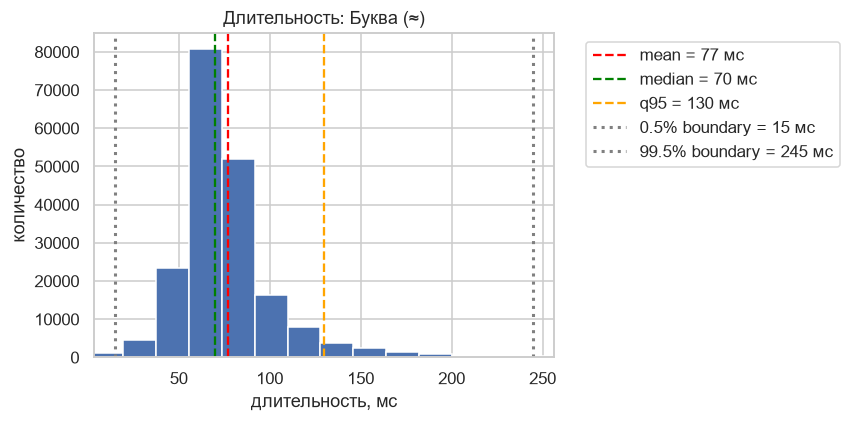

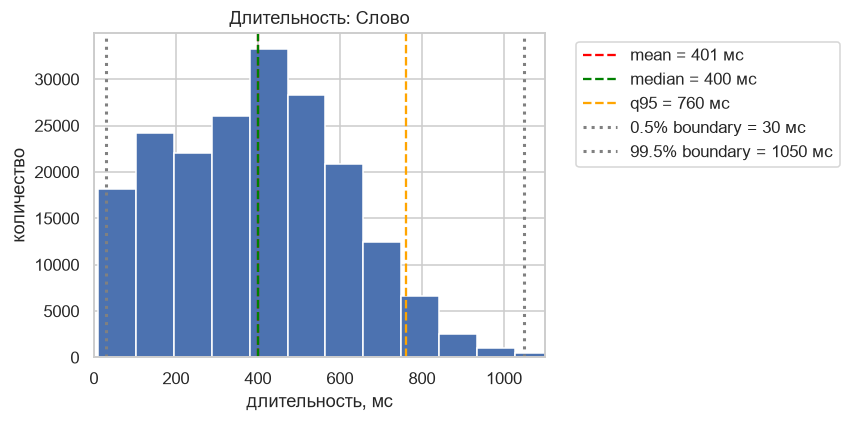

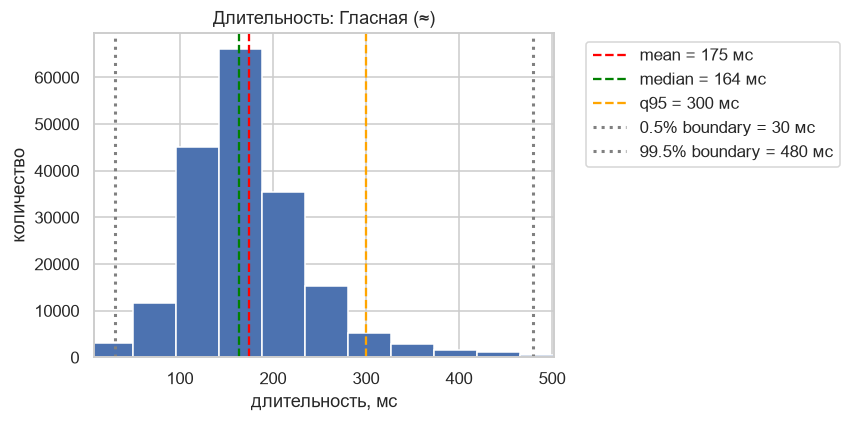

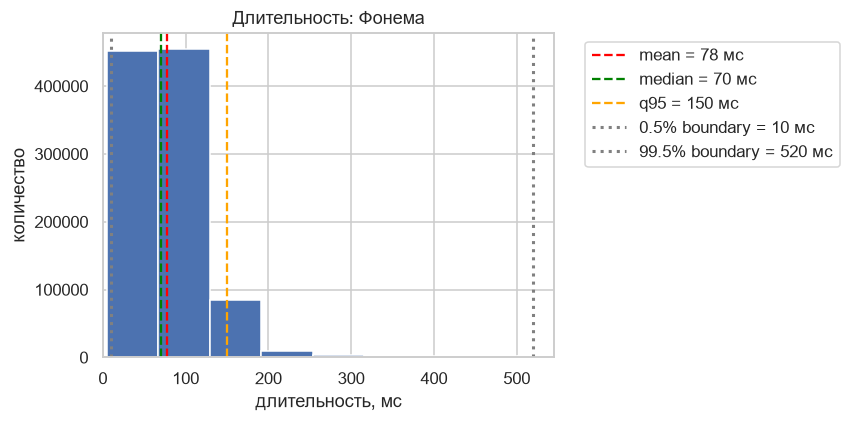

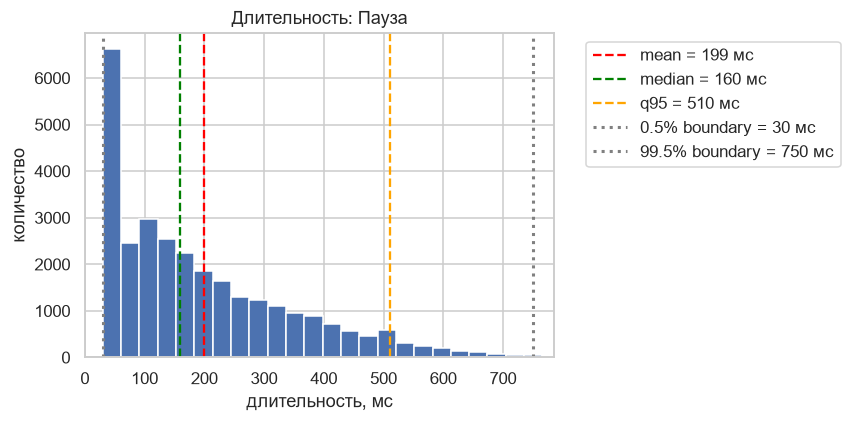

In [12]:
def hist_with_stats(s, title, log=False, bins=60):
    """Гистограмма без удаления данных, с ограничением области видимости и линиями границ."""
    fig, ax = plt.subplots(figsize=(8, 4))
    
    if log:
        s = s[s > 0]
        x = np.log10(s)
        ax.hist(x, bins=bins, color='#4C72B0')
        for v, name, c in [(s.mean(), 'mean', 'red'), (s.median(), 'median', 'green'), (s.quantile(.95), 'q95', 'orange')]:
            ax.axvline(np.log10(v), color=c, ls='--', label=f'{name} = {v:.0f} мс')
        ax.set_xlabel('log10(длительность, мс)')
    else:
        low = s.quantile(0.005)
        hi = s.quantile(0.995)
        
        ax.hist(s, bins=bins, color='#4C72B0')
        
        for v, name, c in [(s.mean(), 'mean', 'red'), (s.median(), 'median', 'green'), (s.quantile(.95), 'q95', 'orange')]:
            ax.axvline(v, color=c, ls='--', label=f'{name} = {v:.0f} мс')
            
        ax.axvline(low, color='gray', ls=':', lw=2, label=f'0.5% boundary = {low:.0f} мс')
        ax.axvline(hi, color='gray', ls=':', lw=2, label=f'99.5% boundary = {hi:.0f} мс')
        
        padding = (hi - low) * 0.05
        ax.set_xlim(max(0, low - padding), hi + padding)
        
        ax.set_xlabel('длительность, мс')
        
    ax.set_ylabel('количество')
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

for name, s in series.items():
    hist_with_stats(s, f'Длительность: {name}')

### 2.1 Гистограммы логарифма длительностей

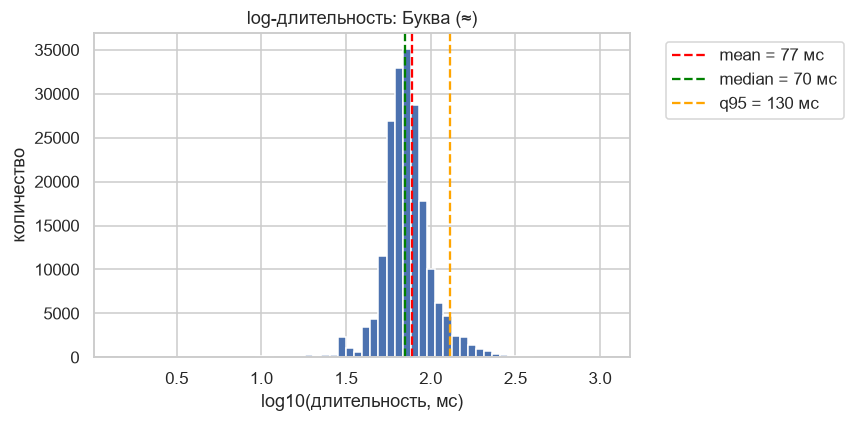

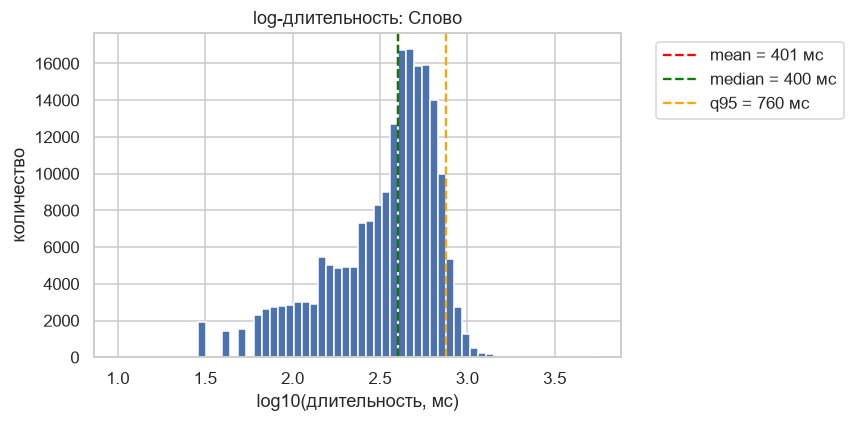

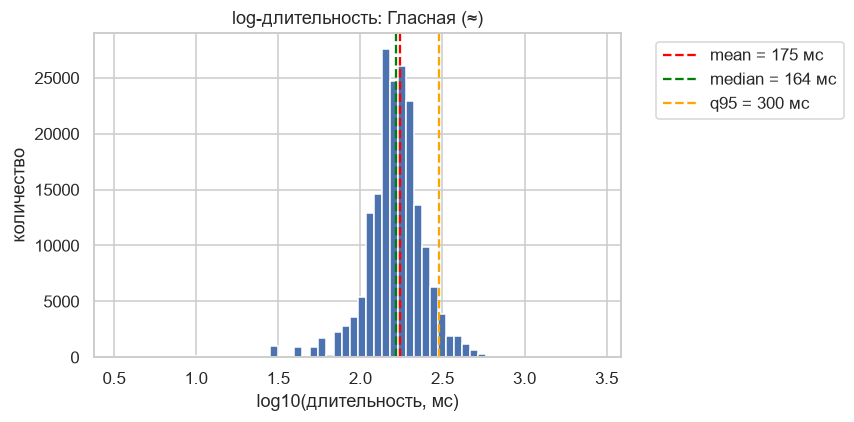

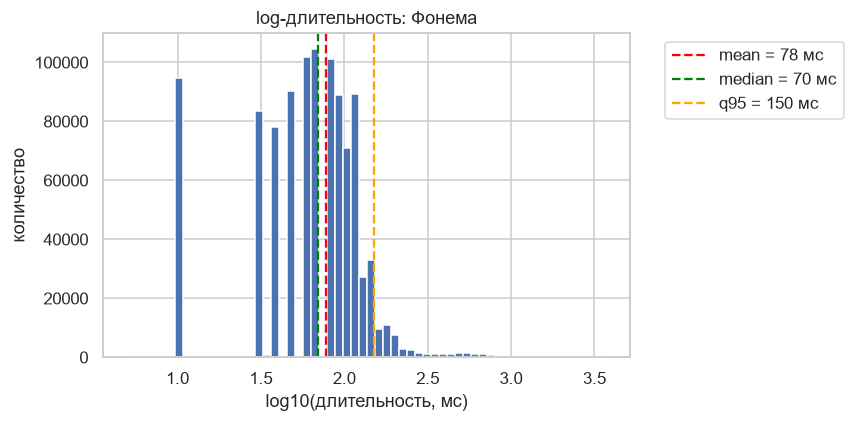

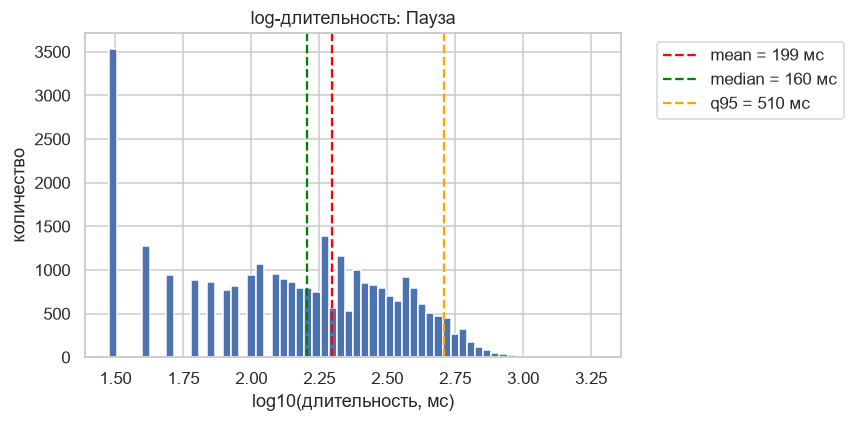

In [13]:
for name, s in series.items():
    hist_with_stats(s, f'log-длительность: {name}', log=True)

## 3. Классы пауз

### 3.1 Пунктуация: доля пауз и длительность

,n_tokens,pause_rate,mean_pause_ms,median_pause_ms
punct_class,,,,
semicolon,1,1.000,720.000,720.0
period,10182,0.954,223.843,180.0
ellipsis,1863,0.930,205.964,170.0
exclaim,617,0.925,217.776,180.0
question,983,0.894,216.439,180.0
closing,429,0.748,240.187,210.0
comma,14551,0.549,163.559,100.0
dash,8362,0.539,197.720,150.0
none,142716,0.026,196.689,180.0


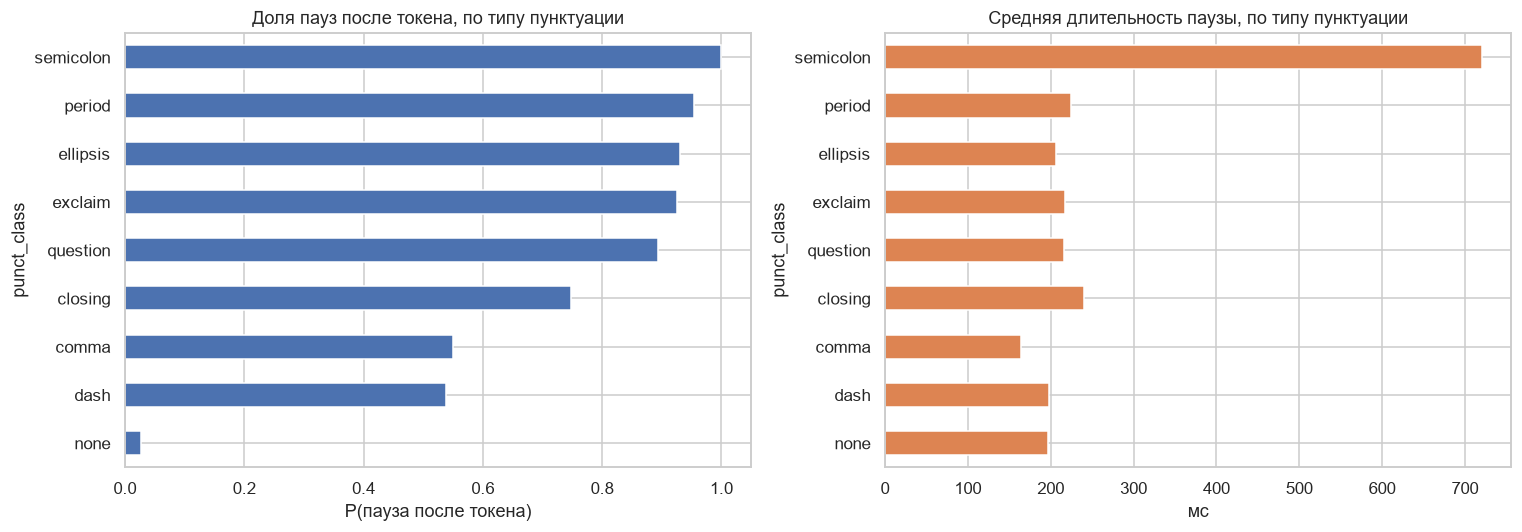

In [14]:
by_punct = work.groupby('punct_class').agg(
    n_tokens=('label', 'size'),
    pause_rate=('is_pause_after', 'mean'),
    mean_pause_ms=('pause_duration', lambda s: s[s > 0].mean() * 1000),
    median_pause_ms=('pause_duration', lambda s: s[s > 0].median() * 1000),
).sort_values('pause_rate', ascending=False)
display(by_punct.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
by_punct.pause_rate.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Доля пауз после токена, по типу пунктуации')
axes[0].set_xlabel('P(пауза после токена)')

by_punct.mean_pause_ms.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].invert_yaxis()
axes[1].set_title('Средняя длительность паузы, по типу пунктуации')
axes[1].set_xlabel('мс')
plt.tight_layout()
plt.show()

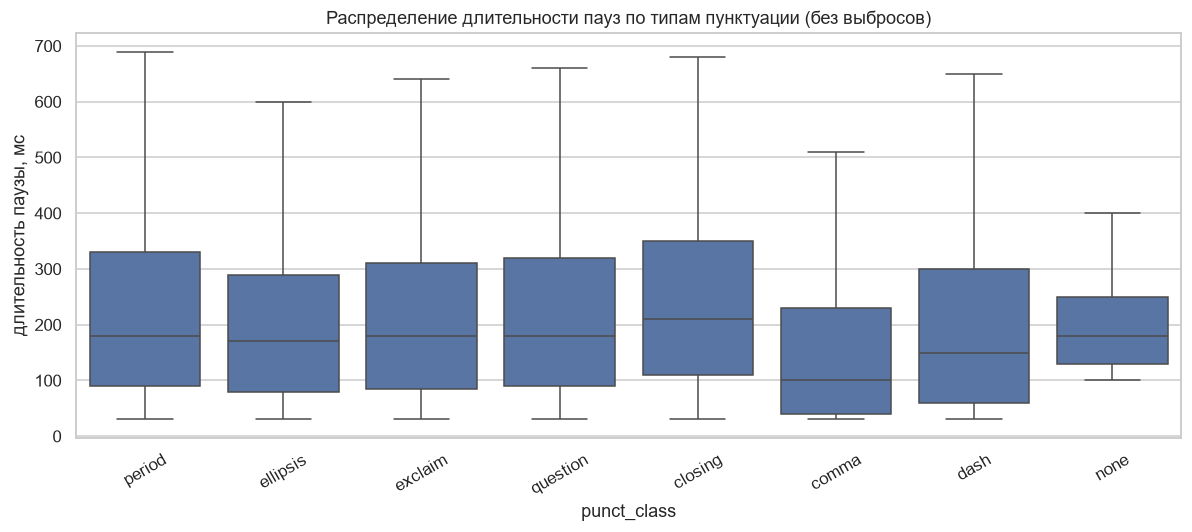

In [15]:
plt.figure(figsize=(11, 5))
top = by_punct[by_punct.n_tokens >= 100].index
sns.boxplot(data=pauses[pauses.punct_class.isin(top)], x='punct_class', y=pauses.pause_duration * 1000,
            order=[c for c in by_punct.index if c in top], showfliers=False)
plt.ylabel('длительность паузы, мс')
plt.title('Распределение длительности пауз по типам пунктуации (без выбросов)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.2 Кластеризация длительностей пауз (KMeans по log-длительности)

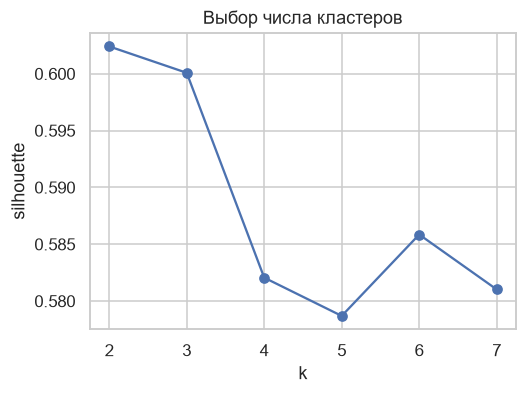

In [16]:
X = np.log(pauses.pause_duration.values).reshape(-1, 1)

# выбор числа кластеров по силуэту (на подвыборке для скорости)
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(len(X), size=min(20000, len(X)), replace=False)
sil = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X[sub_idx])
    sil[k] = silhouette_score(X[sub_idx], labels)
plt.figure(figsize=(5, 3.5))
plt.plot(list(sil), list(sil.values()), marker='o')
plt.xlabel('k'); plt.ylabel('silhouette'); plt.title('Выбор числа кластеров')
plt.show()

,count,mean_ms,min_ms,max_ms
cluster,,,,
0,7498,42.4,30.0,70.0
1,11209,140.0,80.0,210.0
2,10744,369.5,220.0,1870.0


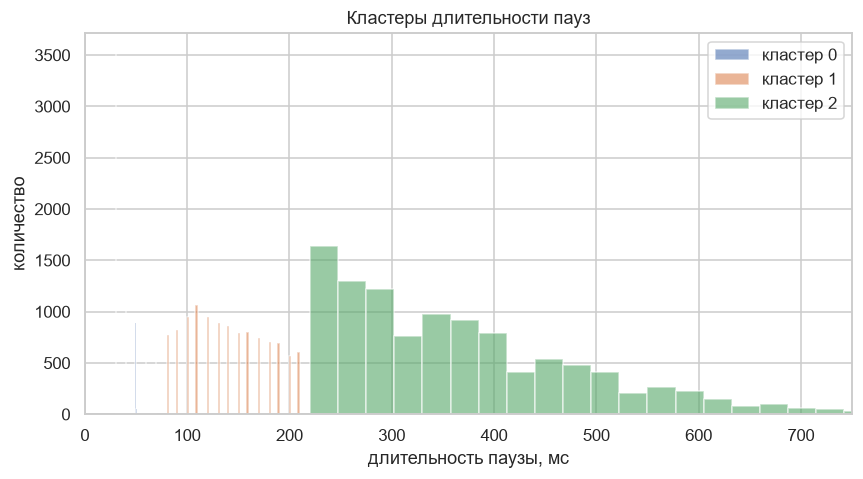

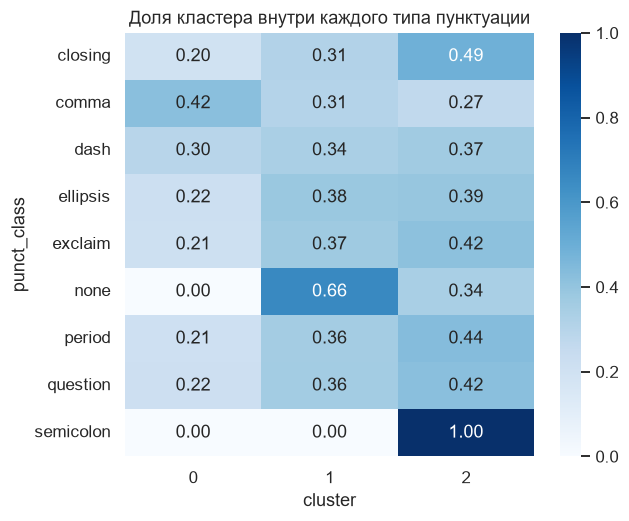

In [17]:
N_CLUSTERS = 3  # при необходимости измените по графику силуэта

km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit(X)
pauses['cluster'] = km.labels_
order = pauses.groupby('cluster').pause_duration.mean().sort_values().index
pauses['cluster'] = pauses.cluster.map({old: new for new, old in enumerate(order)})

cluster_stats = (pauses.groupby('cluster').pause_duration.agg(['count', 'mean', 'min', 'max']) * [1, 1000, 1000, 1000])
cluster_stats['count'] = cluster_stats['count'].astype(int)
cluster_stats.columns = ['count', 'mean_ms', 'min_ms', 'max_ms']
display(cluster_stats.round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
for c in sorted(pauses.cluster.unique()):
    ax.hist(pauses[pauses.cluster == c].pause_duration * 1000, bins=60, alpha=0.6, label=f'кластер {c}')
ax.set_xlim(0, pauses.pause_duration.quantile(0.995) * 1000)
ax.set_xlabel('длительность паузы, мс'); ax.set_ylabel('количество')
ax.set_title('Кластеры длительности пауз')
ax.legend()
plt.show()

cross = pd.crosstab(pauses.punct_class, pauses.cluster, normalize='index')
plt.figure(figsize=(6, 5))
sns.heatmap(cross, annot=True, fmt='.2f', cmap='Blues')
plt.title('Доля кластера внутри каждого типа пунктуации')
plt.show()

## 4. Анализ корреляций

Две задачи:
- **Классификация** (`is_pause_after`, бинарная цель) — используются все токены `work`;
- **Регрессия** (`pause_duration`, непрерывная цель) — только токены с паузой (`pauses`).

Признаки делятся на: категориальные (`punct_class`, `pos_*`), бинарные и числовые.

In [18]:
# Служебные и целевые колонки: в признаки не попадают
NON_FEATURE_COLS = {
    'id', 'set',
    'label', 'label_raw',                        # сам текст токена (утечка/сверхкардинальность)
    'duration',                                  # длительность слова -- разметка
    'is_last_word',                              # только для маски обучения/оценки
    'is_pause_after', 'pause_duration',          # таргеты
}

CATEGORICAL = [
    'punct_class',
    'pos_prev2', 'pos_prev1', 'pos_curr', 'pos_next1', 'pos_next2',
    'prev_word', 'next_word',
    'next_punct_class',
]

BINARY = [
    'is_next_cconj',
    'next_is_stop',
    'is_curr_noun_or_propn',
    'is_curr_propn',
    'has_quote_mark',
    'is_not_last_sentence',
    # 'is_middle_sentence',        # если добавляли
    # 'next_sent_starts_quote',    # если добавляли
]

NUMERIC = [
    'word_len', 'n_syllables',
    'rel_pos', 'pos_in_sentence', 'sent_len',
    'tokens_since_punct', 'tokens_to_punct', 'tokens_to_end',
    'n_sentences_in_id',
    'tokens_to_next_comma', 'commas_left_in_clause',
    # 'sentence_idx_in_id', 'sentences_remaining',   # если возвращали
    # 'prev_sentence_len', 'next_sentence_len',      # если добавляли
]

FEATURES = CATEGORICAL + BINARY + NUMERIC

# Проверки: ничего не потерялось и не пересеклось
missing = [c for c in FEATURES if c not in work.columns]
assert not missing, f'Нет в work: {missing}'
assert len(FEATURES) == len(set(FEATURES)), 'Признак указан в двух списках'
assert not set(FEATURES) & NON_FEATURE_COLS, f'Служебные колонки в признаках: {set(FEATURES) & NON_FEATURE_COLS}'

unlisted = [c for c in work.columns if c not in FEATURES and c not in NON_FEATURE_COLS]
if unlisted:
    print('Колонки не отнесены ни к признакам, ни к служебным:', unlisted)

print('Категориальные:', CATEGORICAL)
print('Бинарные:', BINARY)
print('Числовые:', NUMERIC)

Категориальные: ['punct_class', 'pos_prev2', 'pos_prev1', 'pos_curr', 'pos_next1', 'pos_next2', 'prev_word', 'next_word', 'next_punct_class']
Бинарные: ['is_next_cconj', 'next_is_stop', 'is_curr_noun_or_propn', 'is_curr_propn', 'has_quote_mark', 'is_not_last_sentence']
Числовые: ['word_len', 'n_syllables', 'rel_pos', 'pos_in_sentence', 'sent_len', 'tokens_since_punct', 'tokens_to_punct', 'tokens_to_end', 'n_sentences_in_id', 'tokens_to_next_comma', 'commas_left_in_clause']


### 4.1 Классификация: `is_pause_after`

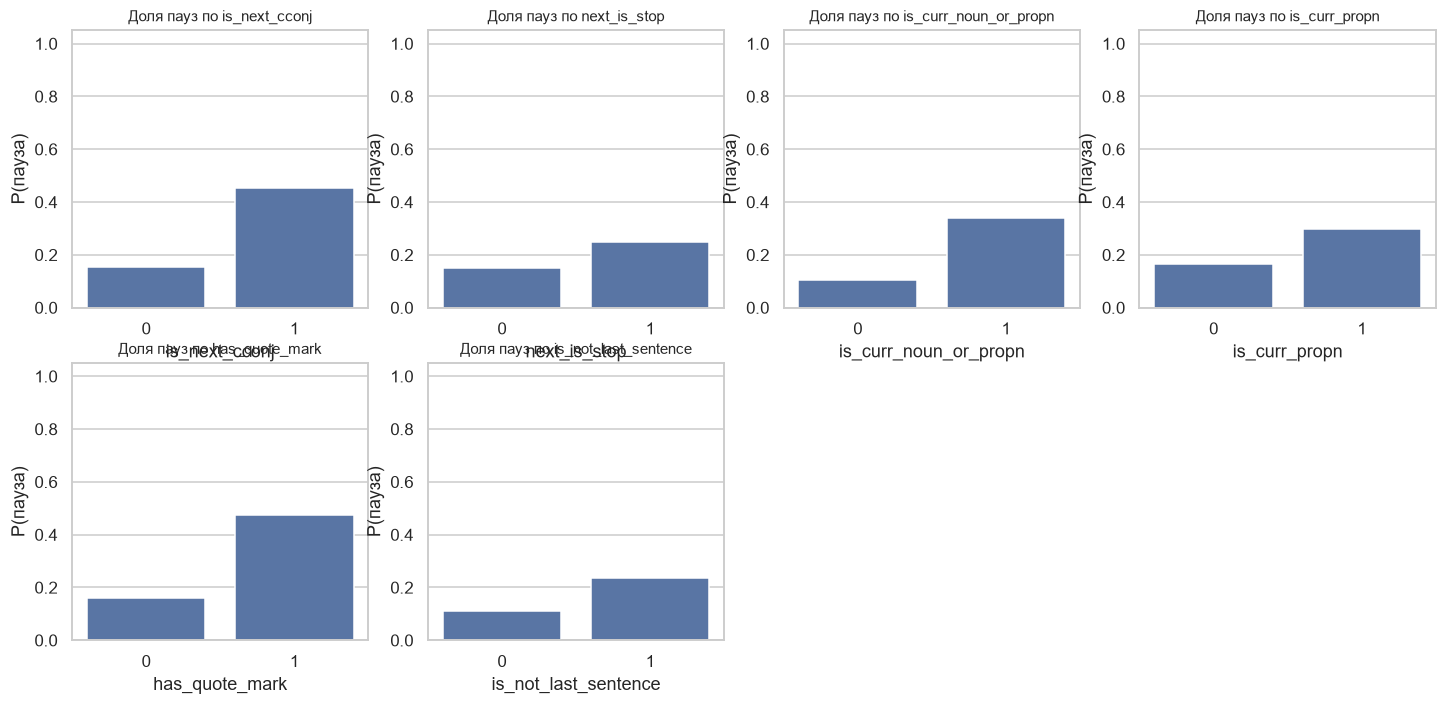

In [19]:
# Бинарные признаки: доля пауз при значении 0/1
n_cols = 4
n_rows = (len(BINARY) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, n_rows * 3.6))
axes = axes.flatten()
for i, col in enumerate(BINARY):
    sns.barplot(x=col, y='is_pause_after', data=work, ax=axes[i], errorbar=None)
    axes[i].set_title(f'Доля пауз по {col}', fontsize=10)
    axes[i].set_ylabel('P(пауза)')
    axes[i].set_ylim(0, 1.05)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

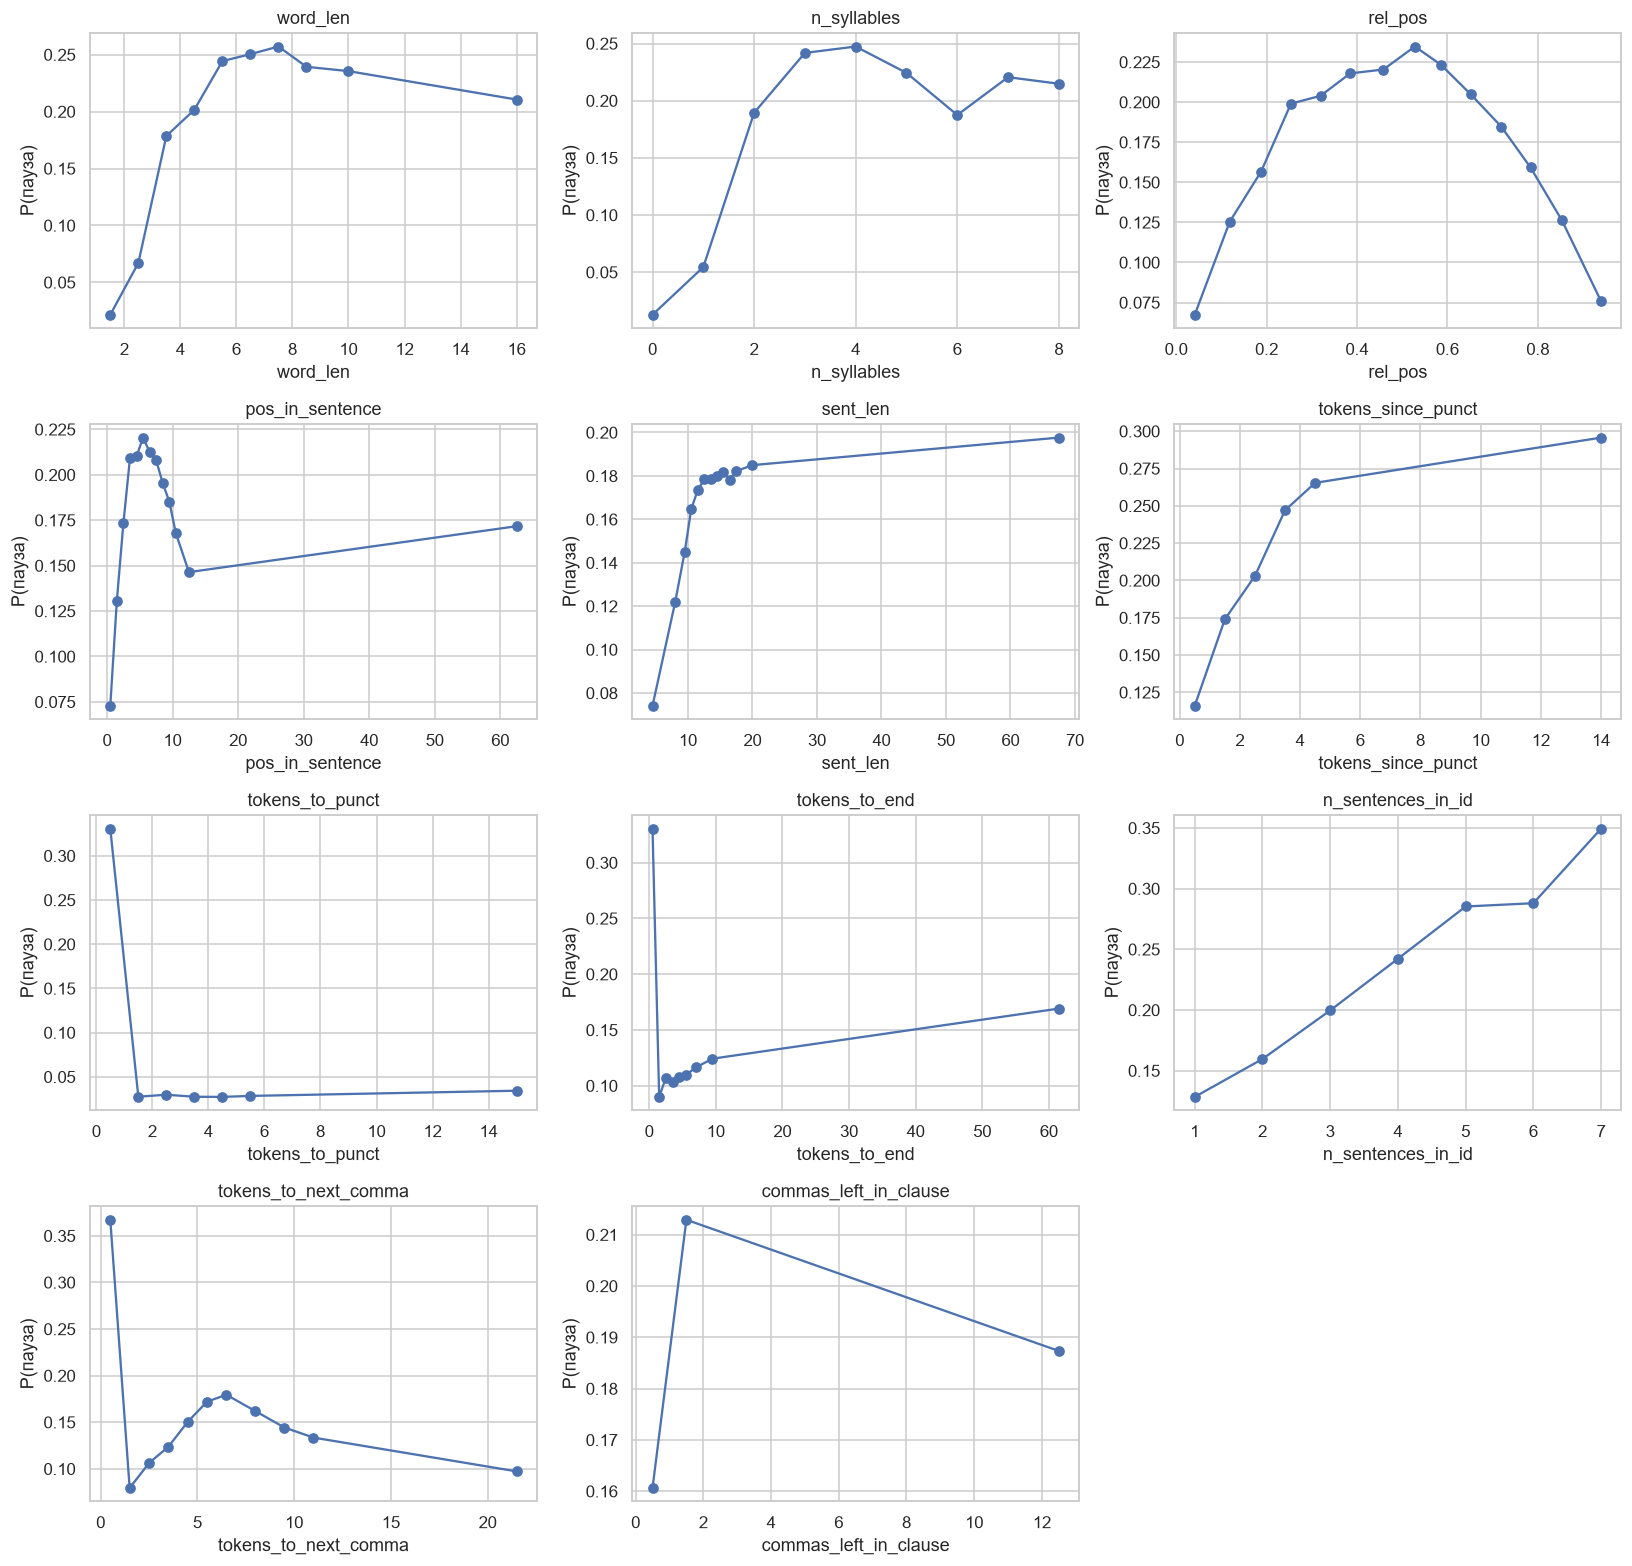

In [20]:
# Числовые признаки: P(пауза) как функция признака (квантильные корзины для широких диапазонов)
def rate_curve(col, min_count=100, q=15):
    x = work[col]
    if x.nunique() > q:
        g = pd.qcut(x, q=q, duplicates='drop')
        r = work.groupby(g, observed=True).is_pause_after.mean()
        xs = np.array([i.mid for i in r.index], dtype=float)
    else:
        grp = work.groupby(x).is_pause_after.agg(['mean', 'size'])
        grp = grp[grp['size'] >= min_count]
        r, xs = grp['mean'], grp.index.values
    return xs, r.values

ncols = 3
nrows = int(np.ceil(len(NUMERIC) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows))
for ax, col in zip(axes.ravel(), NUMERIC):
    xs, r = rate_curve(col)
    ax.plot(xs, r, marker='o')
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('P(пауза)')
for ax in axes.ravel()[len(NUMERIC):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k))

cv = pd.Series({c: cramers_v(work[c], work.is_pause_after) for c in CATEGORICAL}).sort_values(ascending=False)
print("Cramér's V:")
print(cv.round(3).to_string())

Cramér's V:
punct_class         0.768
next_word           0.587
prev_word           0.522
pos_curr            0.328
pos_next1           0.212
pos_prev1           0.181
pos_next2           0.129
next_punct_class    0.125
pos_prev2           0.122


In [ ]:
# Категориальные признаки: доля пауз по категориям
target_col = 'is_pause_after'
n_cols = 3
n_rows = (len(CATEGORICAL) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(CATEGORICAL):
    sns.barplot(x=col, y=target_col, data=work, ax=axes[i], errorbar=None)
    axes[i].set_title(f'Доля пауз по {col} (V={cv[col]:.2f})')
    axes[i].set_ylabel('P(пауза)')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

Error in callback <function _draw_all_if_interactive at 0x0000015955992E80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# Сводка: сила связи каждого признака с is_pause_after
# - точечно-бисериальная корреляция (Пирсон с бинарной целью) для числовых/бинарных
# - взаимная информация (MI) для всех, включая категориальные
y = work.is_pause_after.values

corr_cls = work[NUMERIC_ALL].corrwith(work.is_pause_after).rename('pearson_r')

Xmi = work[CATEGORICAL + NUMERIC_ALL].copy()
for c in CATEGORICAL:
    Xmi[c] = pd.factorize(Xmi[c])[0]
discrete = [c != 'rel_pos' for c in Xmi.columns]
mi = pd.Series(mutual_info_classif(Xmi, y, discrete_features=discrete, random_state=RANDOM_STATE),
               index=Xmi.columns, name='mutual_info')

summary_cls = pd.concat([corr_cls, mi], axis=1).sort_values('mutual_info', ascending=False)
display(summary_cls.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
c = corr_cls.reindex(corr_cls.abs().sort_values().index)
axes[0].barh(c.index, c.values, color=np.where(c.values > 0, '#4C72B0', '#C44E52'))
axes[0].set_title('Корреляция с is_pause_after (Пирсон)')
m = mi.sort_values()
axes[1].barh(m.index, m.values, color='#55A868')
axes[1].set_title('Взаимная информация с is_pause_after')
plt.tight_layout()
plt.show()

NameError: name 'work' is not defined

### 4.2 Регрессия: `pause_duration`

Только токены, где пауза есть. Для числовых признаков — корреляционная матрица (Спирмен устойчив к выбросам и нелинейности), для бинарных и категориальных — распределения длительности по значениям.

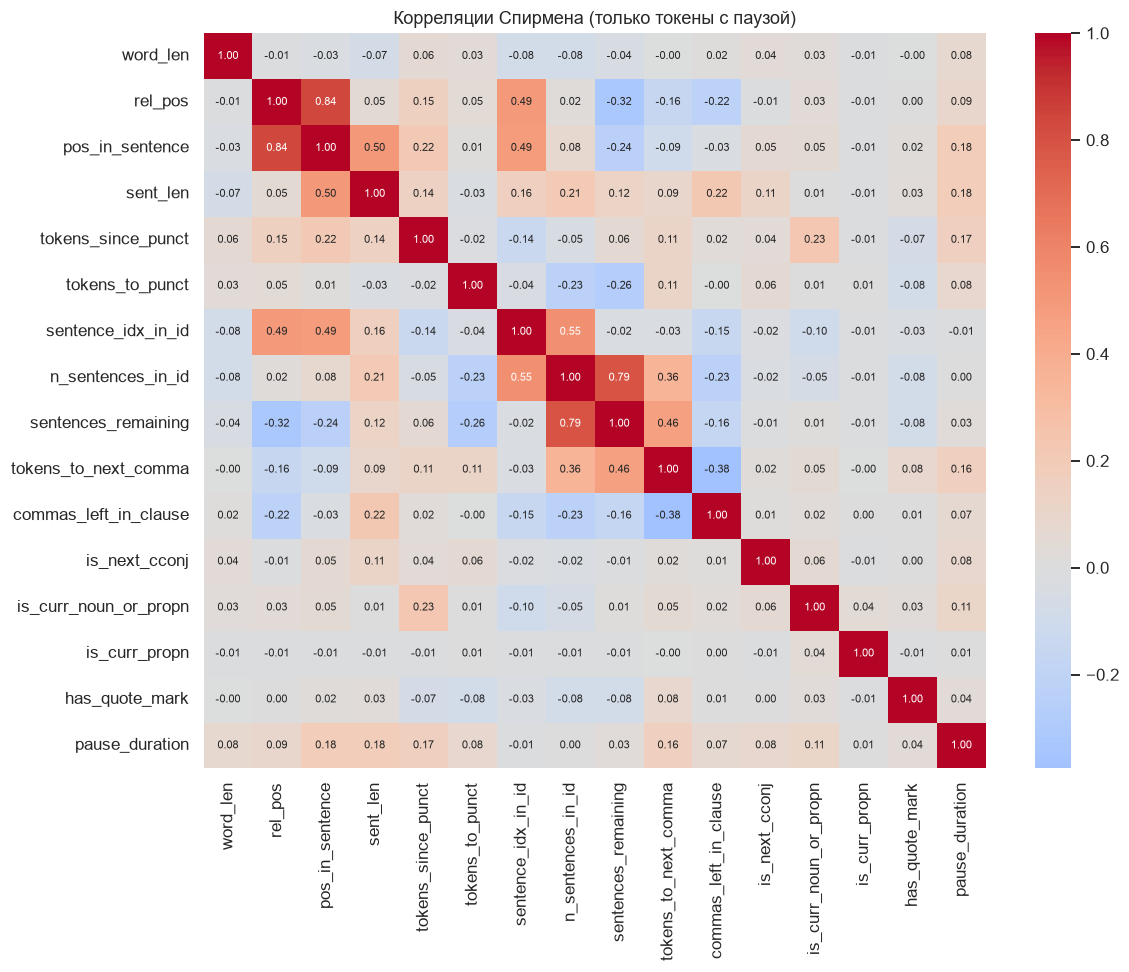

,spearman_with_pause_duration
pos_in_sentence,0.182
sent_len,0.178
tokens_since_punct,0.166
tokens_to_next_comma,0.162
is_curr_noun_or_propn,0.105
rel_pos,0.088
is_next_cconj,0.085
tokens_to_punct,0.084
word_len,0.076
commas_left_in_clause,0.066


In [ ]:
cols = NUMERIC + BINARY + ['pause_duration']
corr = pauses[cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Корреляции Спирмена (только токены с паузой)')
plt.tight_layout()
plt.show()

target_corr = corr['pause_duration'].drop('pause_duration')
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
display(target_corr.to_frame('spearman_with_pause_duration').round(3))

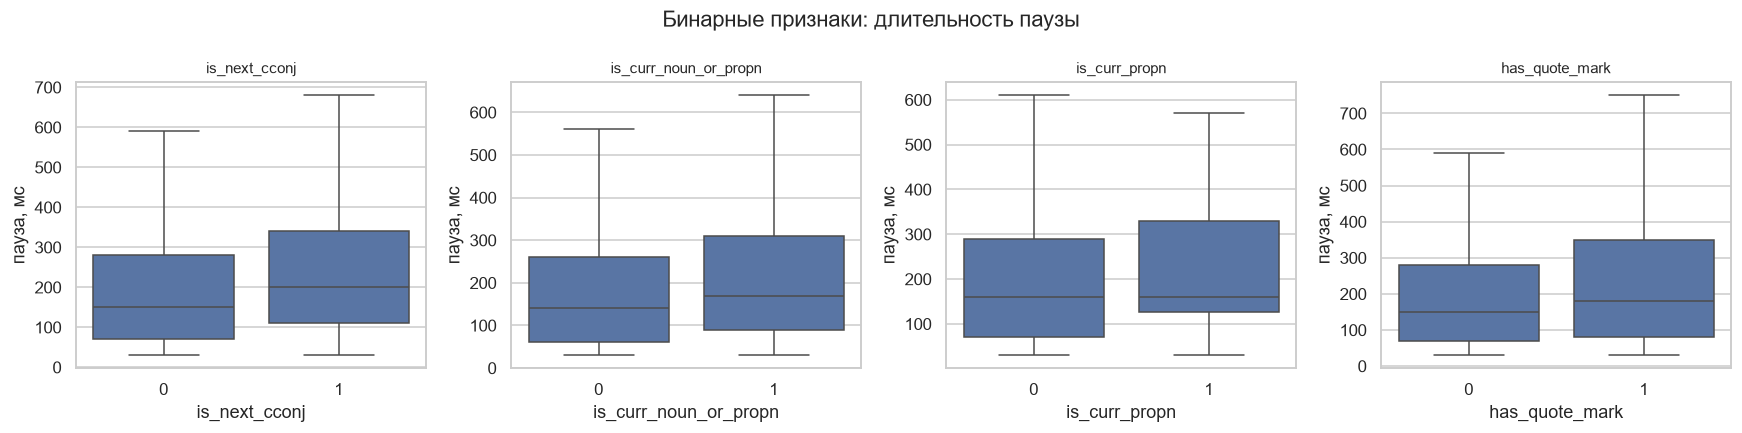

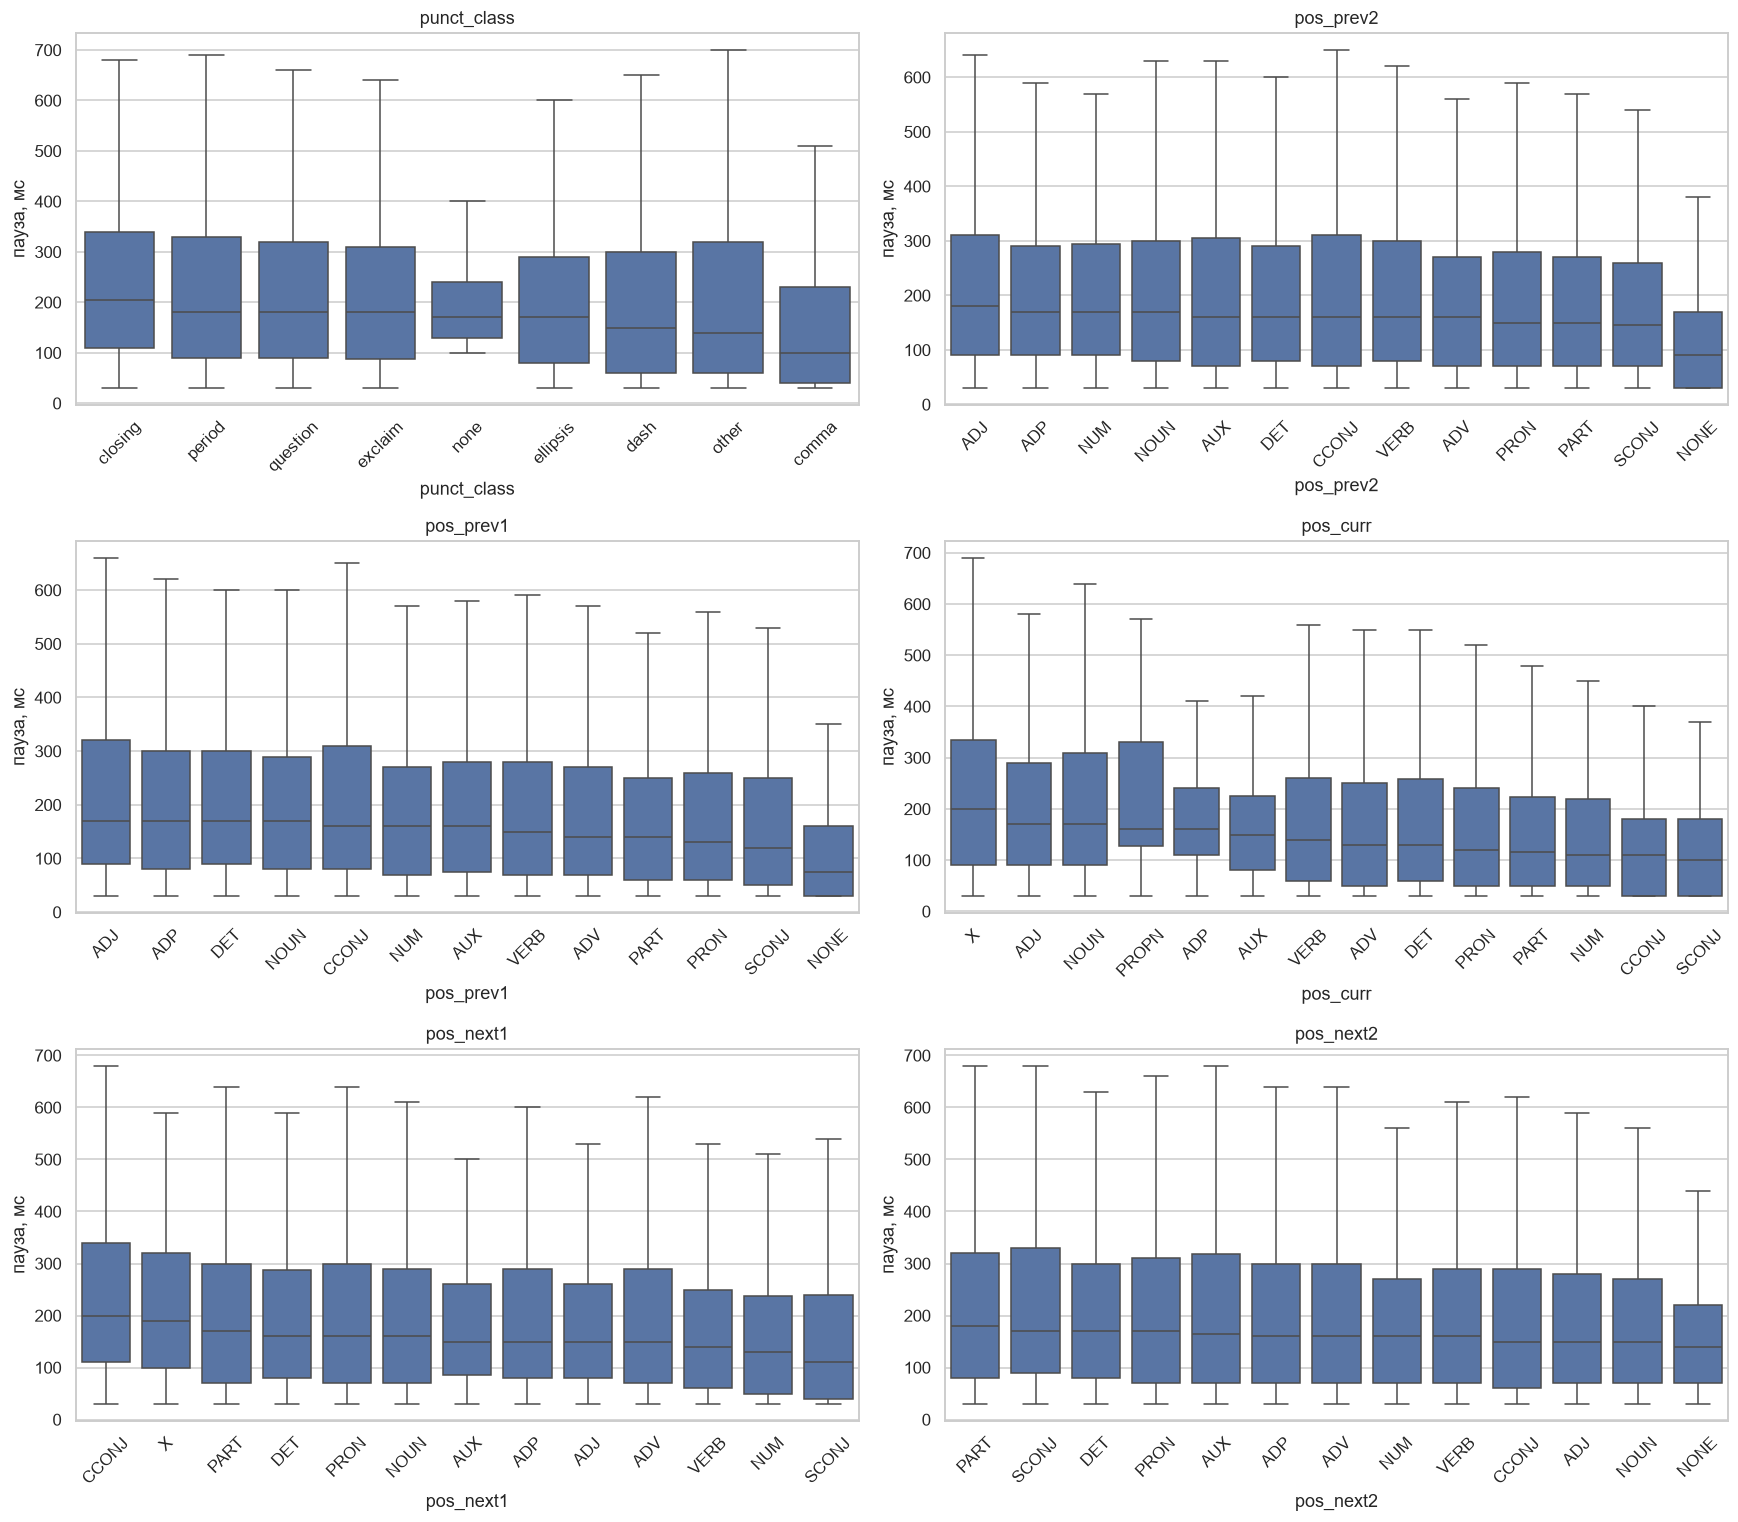

In [ ]:
# Бинарные признаки: длительность паузы при значении 0/1
fig, axes = plt.subplots(1, len(BINARY), figsize=(4 * len(BINARY), 4), squeeze=False)
for ax, col in zip(axes[0], BINARY):
    sns.boxplot(data=pauses, x=col, y=pauses.pause_duration * 1000, ax=ax, showfliers=False)
    ax.set_title(col, fontsize=10); ax.set_ylabel('пауза, мс')
plt.suptitle('Бинарные признаки: длительность паузы')
plt.tight_layout()
plt.show()

# Категориальные признаки: длительность паузы по категориям
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for ax, col in zip(axes.ravel(), CATEGORICAL):
    vc = pauses[col].value_counts()
    keep = vc[vc >= 50].index
    order = pauses[pauses[col].isin(keep)].groupby(col).pause_duration.median().sort_values(ascending=False).index
    sns.boxplot(data=pauses[pauses[col].isin(keep)], x=col, y=pauses.pause_duration * 1000,
                order=order, ax=ax, showfliers=False)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(col); ax.set_ylabel('пауза, мс')
plt.tight_layout()
plt.show()

## 5. Поиск технического шума

Паузы в TextGrid, которые могут быть ошибками выравнивания: очень короткие (< 100 мс) и аномально длинные (> 400 мс). Красным подсвечены короткие паузы, фиолетовым — длинные.

**Замечание:** `prepare_training_data.py` уже зануляет паузы класса `none` вне диапазона 100–400 мс, поэтому в `df` короткие/длинные паузы остались только после токенов с пунктуацией. Чтобы посмотреть и занулённые паузы, ищите прямо в TextGrid.

In [ ]:
def find_pause_files(pause_df, kind='short', n=4, none_only=False):
    """Случайные `id` с хотя бы одной короткой (short) или длинной (long) паузой."""
    d = pause_df[pause_df.pause_duration > 0]
    if none_only:
        d = d[d.punct_class == 'none']
    if kind == 'short':
        d = d[d.pause_duration * 1000 < SHORT_PAUSE_MS]
    else:
        d = d[d.pause_duration * 1000 > LONG_PAUSE_MS]
    candidates = d.id.unique()
    print(f'{kind}: кандидатов {len(candidates)}')
    return random.sample(list(candidates), min(n, len(candidates)))


def plot_waveform_with_textgrid(wave_id: str):
    """Осциллограмма файла с границами слов/пауз из TextGrid и плеером."""
    wav_path = AUDIO_DIR / f'{wave_id}.wav'
    tg_path = os.path.join(ALIGN_DIR, f'{wave_id}.TextGrid')

    audio, sr = sf.read(str(wav_path))
    tg = textgrid.openTextgrid(str(tg_path), True)
    words_tier, phones_tier = tg.tiers

    fig, ax = plt.subplots(figsize=(16, 4))
    t = np.arange(len(audio)) / sr
    ax.plot(t, audio, color='steelblue', linewidth=0.5)

    for entry in words_tier.entries:
        dur_ms = (entry.end - entry.start) * 1000
        if entry.label == '' and dur_ms < SHORT_PAUSE_MS:
            color, alpha = 'red', 0.4
        elif entry.label == '' and dur_ms > LONG_PAUSE_MS:
            color, alpha = 'purple', 0.4
        else:
            color, alpha = 'gray', (0.4 if entry.label == '' else 0.15)
        ax.axvspan(entry.start, entry.end, color=color, alpha=alpha)
        label = entry.label if entry.label else '<SIL>'
        ax.text((entry.start + entry.end) / 2, ax.get_ylim()[1] * 0.85, label,
                ha='center', fontsize=8, rotation=90 if entry.label else 0)

    ax.set_xlim(0, t[-1])
    ax.set_title(f'{wave_id} — красным: паузы < {SHORT_PAUSE_MS} мс, фиолетовым: паузы > {LONG_PAUSE_MS} мс')
    ax.set_xlabel('Время, с')
    plt.tight_layout()
    plt.show()
    display(Audio(audio, rate=sr))

### 5.1 Короткие паузы

short: кандидатов 6860
Выбранные файлы: ['016672_RUSLAN', '006199_RUSLAN', '001606_RUSLAN', '019001_RUSLAN']


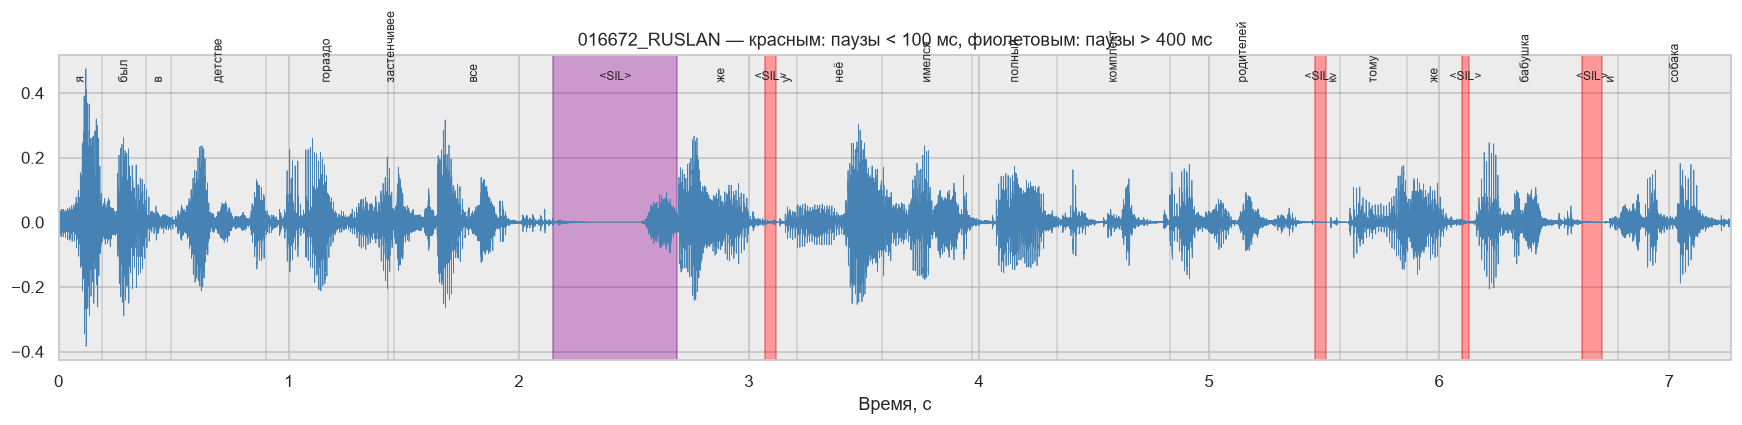

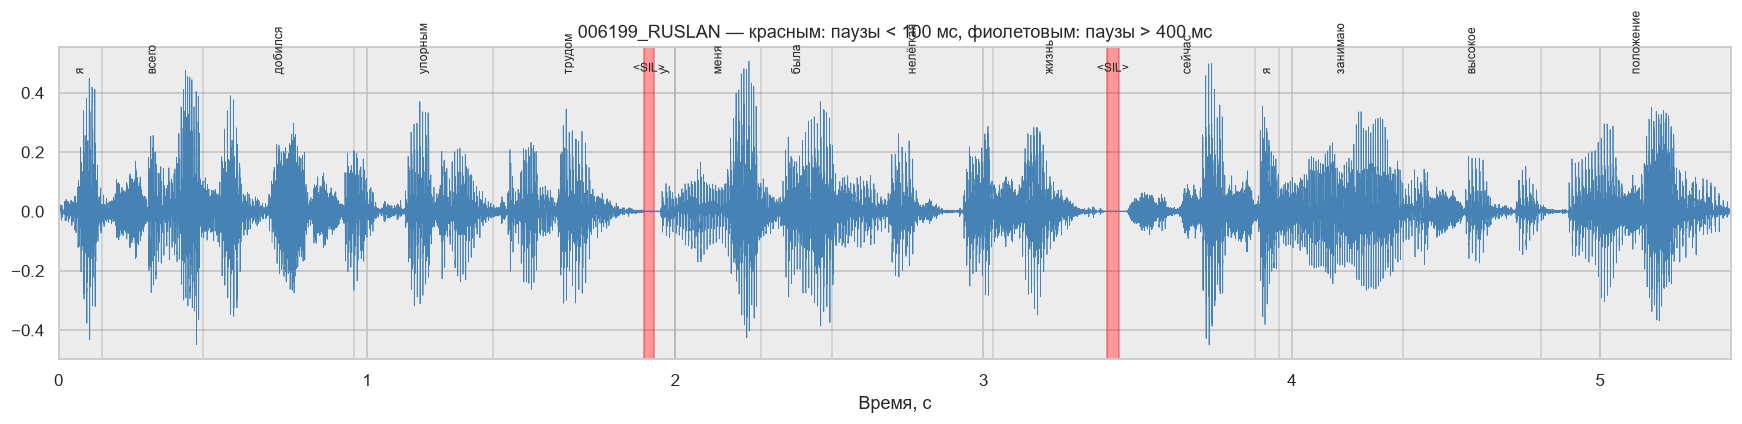

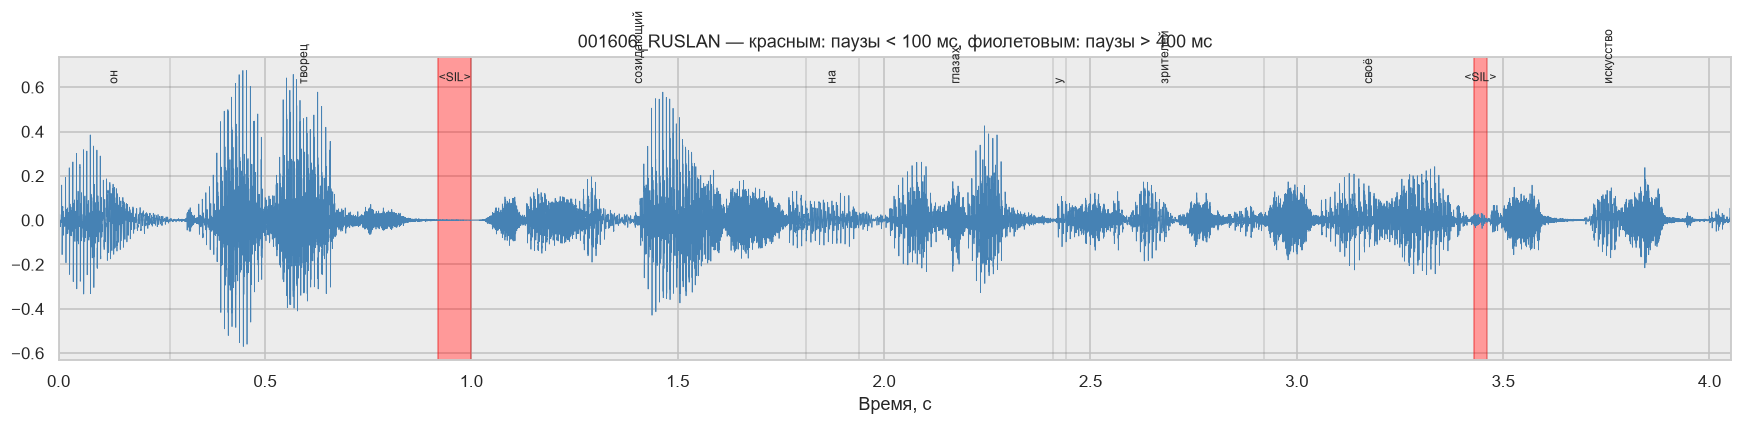

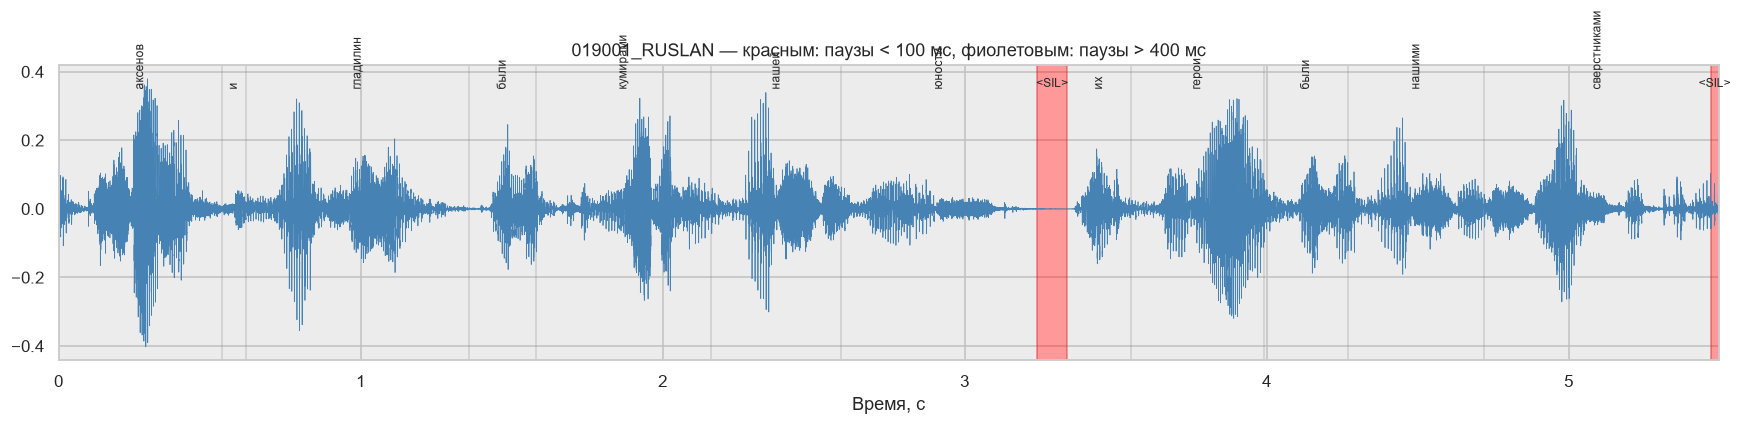

In [ ]:
short_ids = find_pause_files(work, 'short')
print('Выбранные файлы:', short_ids)
for wid in short_ids:
    plot_waveform_with_textgrid(wid)

### 5.2 Аномально длинные паузы

long: кандидатов 2731
Выбранные файлы: ['017223_RUSLAN', '016243_RUSLAN', '015866_RUSLAN', '014563_RUSLAN']


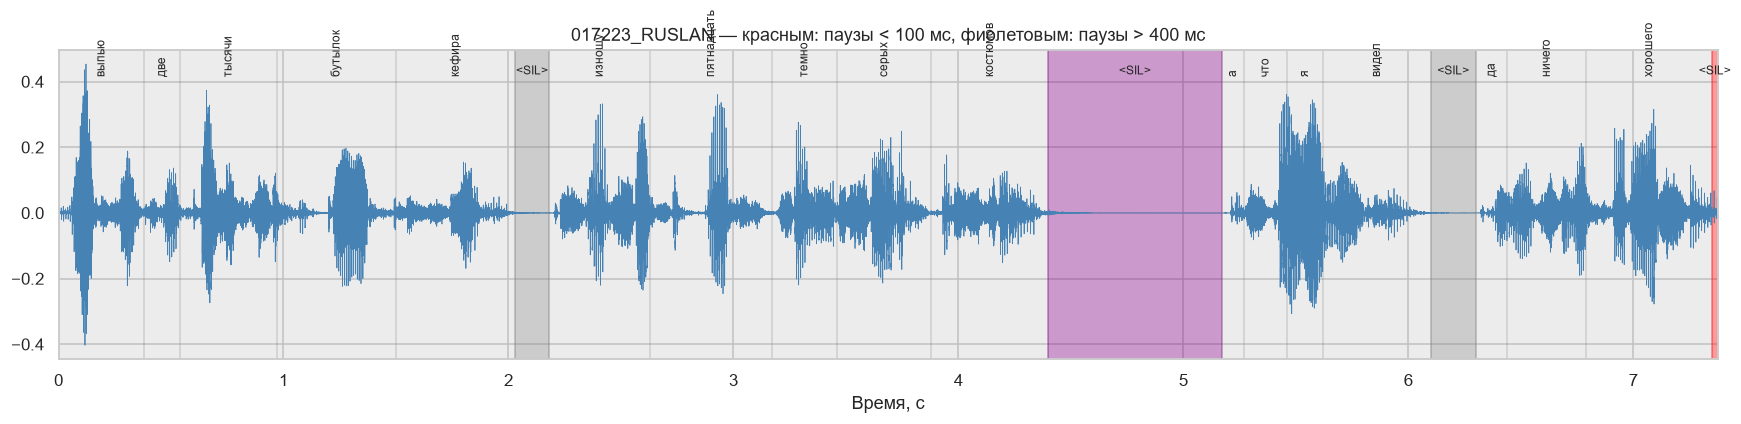

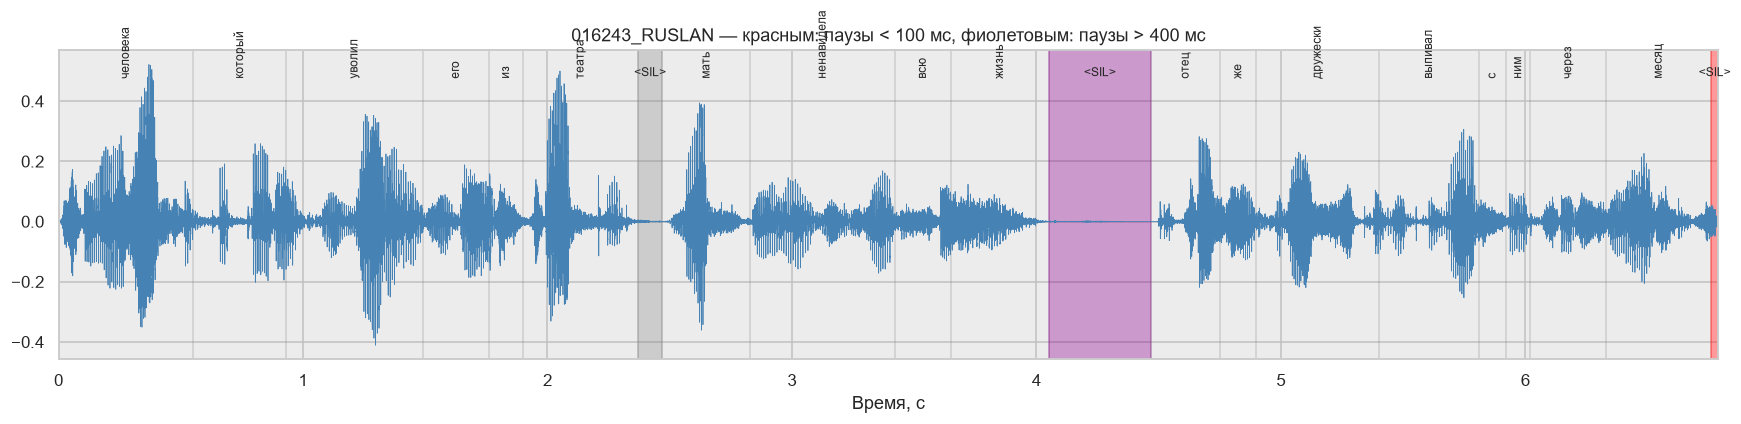

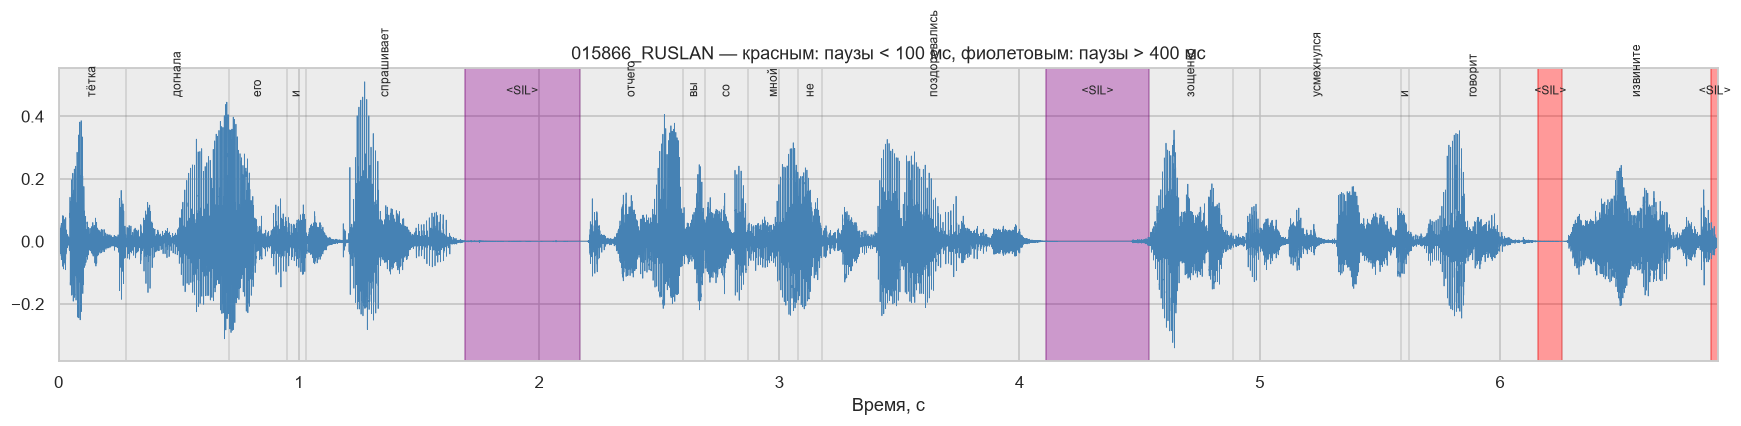

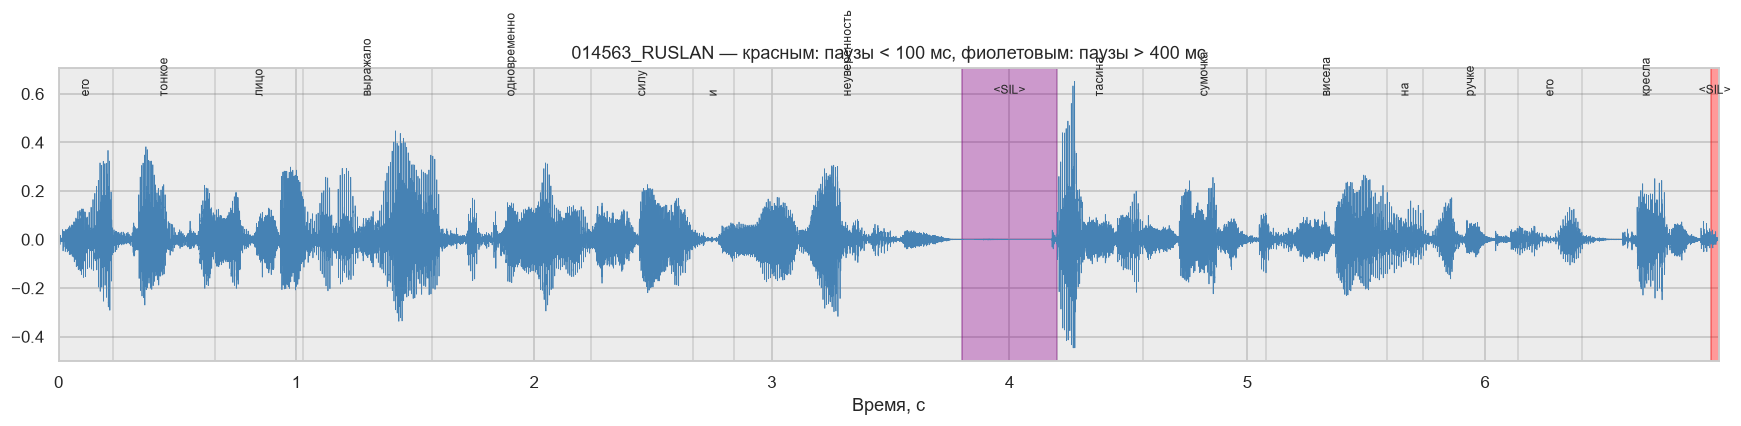

In [ ]:
long_ids = find_pause_files(work, 'long')
print('Выбранные файлы:', long_ids)
for wid in long_ids:
    plot_waveform_with_textgrid(wid)

## 6. Выводы

*Будут сформулированы после получения результатов запуска ноутбука.*